In [1]:
import json
import pathlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
plt.rcParams.update({"font.size":13})
from matplotlib.ticker import MaxNLocator

### Water 6-31 g

In [3]:
folder = "../outputs/water_6_31g/"
p = pathlib.Path(folder)
filepaths = list(p.glob("*.json"))


In [4]:
p.parts[-1]

'water_6_31g'

In [5]:
metrics_data = []
for f in filepaths:
    with open(f, "r") as fp:
        metrics_data.append(json.load(fp))

In [6]:
for i in range(10):
    print(metrics_data[i]["OO_data"]["molpath"])

hamiltonians/water_6-31g/H2O_OH0.8000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH0.8000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH2.0000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH2.5000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH1.5000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH2.0000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH1.5000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH0.9580_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH2.5000_104.5000_6-31g.chk
hamiltonians/water_6-31g/H2O_OH0.9580_104.5000_6-31g.chk


In [7]:
bond_distances_by_h = {'hamiltonians/water_6-31g/H2O_OH0.8000_104.5000_6-31g.chk': 0.8,
                      'hamiltonians/water_6-31g/H2O_OH0.9580_104.5000_6-31g.chk': 0.958,
                      'hamiltonians/water_6-31g/H2O_OH1.5000_104.5000_6-31g.chk': 1.5,
                      'hamiltonians/water_6-31g/H2O_OH2.0000_104.5000_6-31g.chk': 2.0,
                      'hamiltonians/water_6-31g/H2O_OH2.5000_104.5000_6-31g.chk': 2.5,
                      'hamiltonians/water/H2O_OH2.0000_104.5000.chk': 2.0,
                     'hamiltonians/water/H2O_OH0.9580_104.5000.chk': 0.958,
                     'hamiltonians/water/H2O_OH2.5000_104.5000.chk': 2.5,
                     'hamiltonians/water/H2O_OH1.6430_104.5000.chk': 1.643,
                     'hamiltonians/water/H2O_OH2.0000_104.5000.FCIDUMP': 2.0,
                     'hamiltonians/water/H2O_OH0.9580_104.5000.FCIDUMP': 0.958,
                     'hamiltonians/water/H2O_OH2.5000_104.5000.FCIDUMP': 2.5,
                     'hamiltonians/water/H2O_OH1.6430_104.5000.FCIDUMP': 1.643}

In [8]:
metrics_data[0].keys()

dict_keys(['args', 'OO_data', 'E_FCI', 'Eckart', 'used_sectors_weights_dims'])

In [9]:
metric_series = []
for i, metric in enumerate(metrics_data):

    used_sectors_weights_dims = metric["used_sectors_weights_dims"]
    weights = [v[0] for k, v in used_sectors_weights_dims.items()]
    dims = [v[1] for k, v in used_sectors_weights_dims.items()]
    largest_dim = np.max(dims)
    total_dim = np.sum(dims)
    
    s = pd.Series({
        "id": i,
        "bond_distance": bond_distances_by_h[metric["OO_data"]["molpath"]],
        "parity": pathlib.Path(metric["OO_data"]["parity"]).parts[-1],
        "cost": metric["OO_data"]["cost_function"],
        "reference": metric["OO_data"]["reference"],
        "elapsed": metric["OO_data"]["elapsed"],
        "cost_before": metric["OO_data"]["cost_before"],
        "cost_after": metric["OO_data"]["cost_after"],
        "Eckart": metric["Eckart"],
        "largest_dim": largest_dim,
        "total_dim": total_dim,
        "sector_count": len(weights)
    })
    # if metric["OO_data"]["converged"] or s["elapsed"] == 0:
        # metric_series.append(s)
    metric_series.append(s)

df = pd.concat(metric_series, axis=1).T
print(df.shape)

(10, 12)


In [10]:
df

,id,bond_distance,parity,cost,reference,elapsed,cost_before,cost_after,Eckart,largest_dim,total_dim,sector_count
0,0,0.8,13_sens.txt,NC,fci,0,4.753266,4.753266,0.000026,1287,107063,222
1,1,0.8,13_sens.txt,NC,fci,39124.283669,4.753266,4.355459,0.000026,1287,94043,190
2,2,2.0,13_sens.txt,NC,fci,39075.106792,4.316222,3.934583,0.000028,1287,106977,221
3,3,2.5,13_sens.txt,NC,fci,43842.898078,4.228727,3.716747,0.000028,1287,100603,208
4,4,1.5,13_sens.txt,NC,fci,45175.179056,4.688733,4.215745,0.000027,1287,100985,206
5,5,2.0,13_sens.txt,NC,fci,0,4.316222,4.316222,0.000028,1287,127137,267
6,6,1.5,13_sens.txt,NC,fci,0,4.688733,4.688733,0.000027,1287,142215,302
7,7,0.958,13_sens.txt,NC,fci,40252.997741,4.909569,4.312466,0.000027,1287,94379,191
8,8,2.5,13_sens.txt,NC,fci,0,4.228727,4.228727,0.000028,1287,138407,294
9,9,0.958,13_sens.txt,NC,fci,0,4.909569,4.909569,0.000027,1287,130093,274


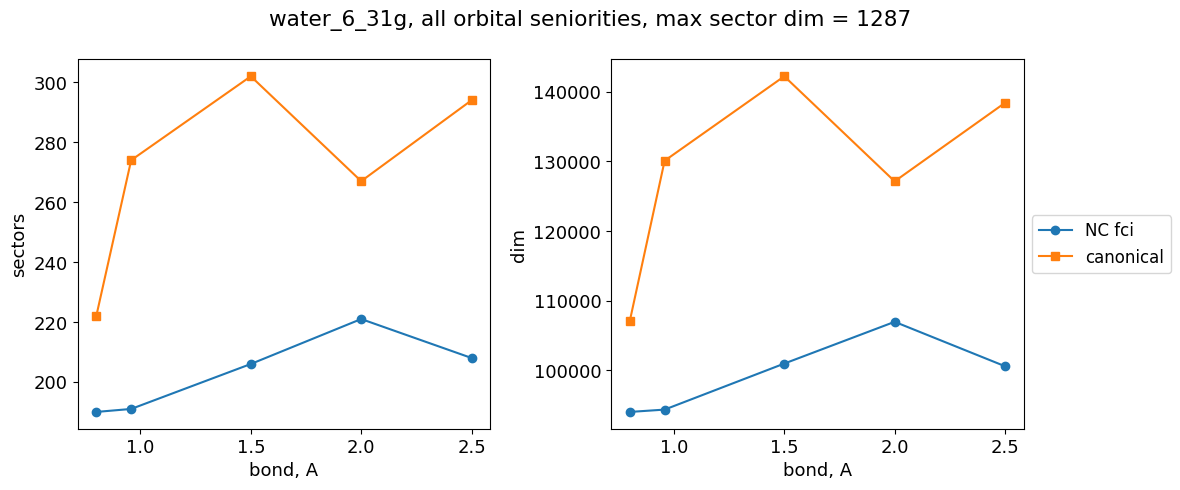

In [11]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

df_opt = df[df["elapsed"] > 0]
df_opt = df_opt.sort_values(by="bond_distance")
# print(df_opt)

df_can = df[df["elapsed"] <1e-10]
df_can = df_can.sort_values(by="bond_distance")
# print(df_can)


axs[0].plot(df_opt["bond_distance"], df_opt["sector_count"], marker="o", label="NC fci")
axs[0].plot(df_can["bond_distance"], df_can["sector_count"], marker="s", label="canonical")

axs[1].plot(df_opt["bond_distance"], df_opt["total_dim"], marker="o", label="NC fci")
axs[1].plot(df_can["bond_distance"], df_can["total_dim"], marker="s", label="canonical")

axs[0].set_xlabel("bond, A")
axs[1].set_xlabel("bond, A")

axs[0].set_ylabel("sectors")
axs[1].set_ylabel("dim")

axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

plt.suptitle(p.parts[-1] + ", all orbital seniorities, max sector dim = " + str(np.max(df["largest_dim"])))

plt.tight_layout()
plt.savefig(folder + "water_6_31g_easy_metrics_sen.png", format="png", dpi=400, bbox_inches="tight")

### Water minimal (to compare with K-based metrics)

In [12]:
folder = "../outputs/water/sector_metrics/"
p = pathlib.Path(folder)
filepaths = list(p.glob("*.json"))


In [13]:
metrics_data = []
for f in filepaths:
    with open(f, "r") as fp:
        metrics_data.append(json.load(fp))

In [14]:
metric_series = []
for i, metric in enumerate(metrics_data):

    used_sectors_weights_dims = metric["used_sectors_weights_dims"]
    weights = [v[0] for k, v in used_sectors_weights_dims.items()]
    dims = [v[1] for k, v in used_sectors_weights_dims.items()]
    largest_dim = np.max(dims)
    total_dim = np.sum(dims)
    
    s = pd.Series({
        "id": i,
        "bond_distance": bond_distances_by_h[metric["OO_data"]["molpath"]],
        "parity": pathlib.Path(metric["OO_data"]["parity"]).parts[-1],
        "cost": metric["OO_data"]["cost_function"],
        "reference": metric["OO_data"]["reference"],
        "elapsed": metric["OO_data"]["elapsed"],
        "cost_before": metric["OO_data"]["cost_before"],
        "cost_after": metric["OO_data"]["cost_after"],
        "Eckart": metric["Eckart"],
        "largest_dim": largest_dim,
        "total_dim": total_dim,
        "sector_count": len(weights)
    })
    # if metric["OO_data"]["converged"] or s["elapsed"] == 0:
        # metric_series.append(s)
    metric_series.append(s)

df = pd.concat(metric_series, axis=1).T
print(df.shape)

(132, 12)


In [25]:
df.iloc[10]["Eckart"]

3.391178852762662e-05

In [27]:
used_sectors_weights_dims = metrics_data[10]["used_sectors_weights_dims"]
weights = [v[0] for k, v in used_sectors_weights_dims.items()]
1 - sum(weights)

2.449090141576349e-06

In [15]:
df

,id,bond_distance,parity,cost,reference,elapsed,cost_before,cost_after,Eckart,largest_dim,total_dim,sector_count
0,0,0.958,parity_7_sens.txt,variance,fci,0,0.179484,0.179484,0.000034,21,63,6
1,1,1.643,parity_water_1.643.txt,variance,hf,0.151506,0.0,0.0,0.000034,47,79,2
2,2,2.0,parity_water_2.000.txt,NC,fci,0,0.047895,0.047895,0.000034,47,79,2
3,3,2.5,parity_core_numbers_2.500.txt,switching_sector,fci,96.166854,-74.740355,-74.740477,0.000034,36,52,2
4,4,2.5,parity_water_2.500.txt,NC,fci,311.458569,0.001924,0.000139,0.000034,47,47,1
...,...,...,...,...,...,...,...,...,...,...,...,...
127,127,2.5,parity_water_2.500.txt,switching_sector,fci,103.4284,-74.740458,-74.740583,0.000034,47,47,1
128,128,2.0,parity_core_numbers_2.000.txt,fixed_sector,fci,0,-74.757616,-74.757616,0.000034,36,116,5
129,129,2.5,parity_water_2.500.txt,decoupled,fci,112.840466,-74.740458,-74.740583,0.000034,47,47,1
130,130,2.0,parity_water_2.000.txt,variance,fci,0,0.019141,0.019141,0.000034,47,79,2


In [16]:
local_number_parities = ['parity_core_numbers_0.958.txt', 'parity_core_numbers_1.643.txt',
       'parity_core_numbers_2.000.txt', 'parity_core_numbers_2.500.txt']

senquart_parities = ['parity_water_0.9580.txt', 'parity_water_1.643.txt',
       'parity_water_2.000.txt', 'parity_water_2.500.txt']

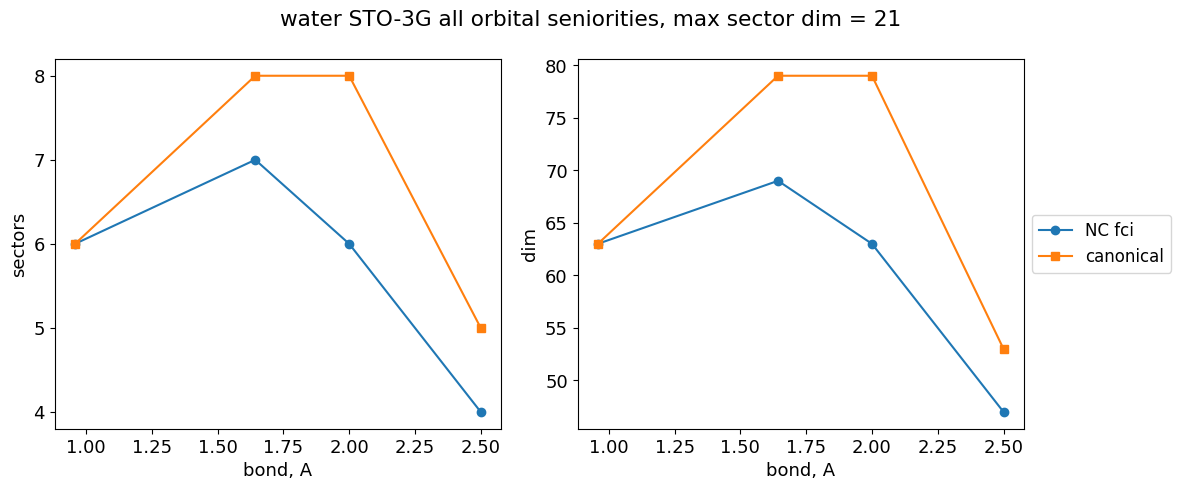

In [21]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

df_opt = df[(df["elapsed"] > 0) * (df["parity"] == "parity_7_sens.txt") * (df["cost"] == "NC") * (df["reference"] == "fci")]
df_opt = df_opt.sort_values(by="bond_distance")
# print(df_opt)

df_can = df[(df["elapsed"] <1e-10) * (df["parity"] == "parity_7_sens.txt") * (df["cost"] == "NC") * (df["reference"] == "fci")]
df_can = df_can.sort_values(by="bond_distance")
# print(df_can)


axs[0].plot(df_opt["bond_distance"], df_opt["sector_count"], marker="o", label="NC fci")
axs[0].plot(df_can["bond_distance"], df_can["sector_count"], marker="s", label="canonical")

axs[1].plot(df_opt["bond_distance"], df_opt["total_dim"], marker="o", label="NC fci")
axs[1].plot(df_can["bond_distance"], df_can["total_dim"], marker="s", label="canonical")

axs[0].set_xlabel("bond, A")
axs[1].set_xlabel("bond, A")

axs[0].set_ylabel("sectors")
axs[1].set_ylabel("dim")

axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

max_dim = max(np.max(df_opt["largest_dim"]), np.max(df_can["largest_dim"]))

plt.suptitle("water STO-3G all orbital seniorities, max sector dim = " + str(max_dim))

axs[0].yaxis.set_major_locator(MaxNLocator(integer=True))


plt.tight_layout()
plt.savefig(folder + "water_sto3g_easy_metrics_sen.png", format="png", dpi=400, bbox_inches="tight")

In [20]:
df_opt["largest_dim"]

113    21
55     21
5      21
60     21
Name: largest_dim, dtype: object

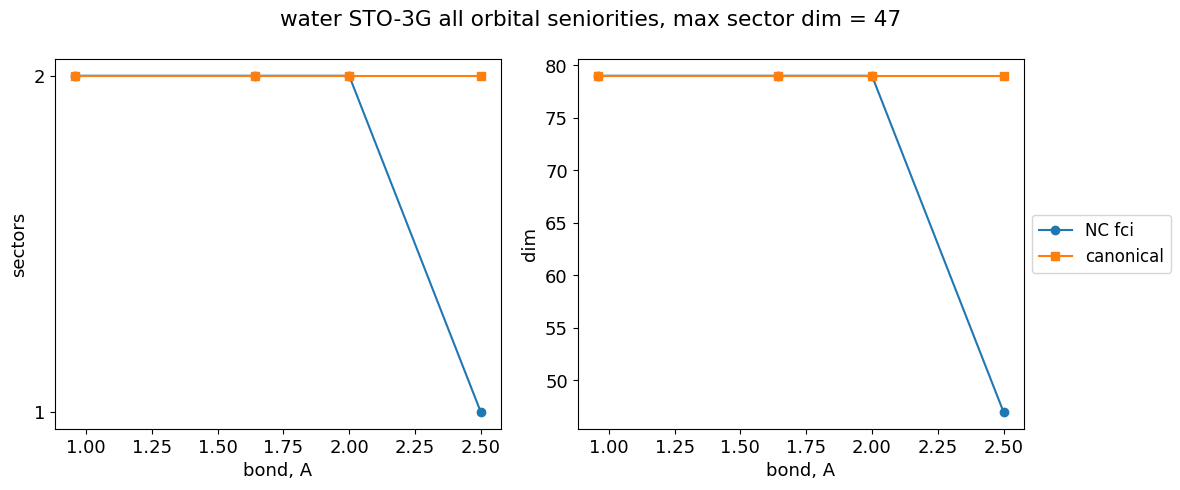

In [23]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))

df_opt = df[(df["elapsed"] > 0) * (df["parity"].isin(senquart_parities)) * (df["cost"] == "NC") * (df["reference"] == "fci")]
df_opt = df_opt.sort_values(by="bond_distance")
# print(df_opt)

df_can = df[(df["elapsed"] <1e-10) * (df["parity"].isin(senquart_parities)) * (df["cost"] == "NC") * (df["reference"] == "fci")]
df_can = df_can.sort_values(by="bond_distance")
# print(df_can)


axs[0].plot(df_opt["bond_distance"], df_opt["sector_count"], marker="o", label="NC fci")
axs[0].plot(df_can["bond_distance"], df_can["sector_count"], marker="s", label="canonical")

axs[1].plot(df_opt["bond_distance"], df_opt["total_dim"], marker="o", label="NC fci")
axs[1].plot(df_can["bond_distance"], df_can["total_dim"], marker="s", label="canonical")

axs[0].set_xlabel("bond, A")
axs[1].set_xlabel("bond, A")

axs[0].set_ylabel("sectors")
axs[1].set_ylabel("dim")

axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

max_dim = max(np.max(df_opt["largest_dim"]), np.max(df_can["largest_dim"]))

plt.suptitle("water STO-3G all orbital seniorities, max sector dim = " + str(max_dim))

axs[0].yaxis.set_major_locator(MaxNLocator(integer=True))


plt.tight_layout()
# plt.savefig(folder + "water_6_31g_easy_metrics_sen.png", format="png", dpi=400, bbox_inches="tight")